# Notebook 04 — GNN Analysis: Evaluation, UMAP, and Cross-Validation

**This notebook analyses the outputs of `scripts/train.py`.**
Run the training script first:
```bash
TLS_DATA_ROOT=/path/to/data python scripts/train.py
```

**Inputs** (produced by `scripts/train.py`):
- `checkpoints/best_model.pt`
- `checkpoints/tls_predictions.csv`
- `checkpoints/tls_embeddings.pt`
- `TLS_DATA_ROOT/processed/tls_graphs.pt`   (for cross-validation)

**Outputs produced here**:
- `evaluation_plots.png` — ROC/PR curves + confusion matrices
- `score_distributions.png` — score histograms by class
- `umap_embeddings.png` — 2D embedding projection
- `cv_results.csv / cv_summary.csv` — 5-fold cross-validation


In [1]:
import os, sys, json, time, math, random
from pathlib import Path

from collections import Counter

PROJECT_ROOT = Path(os.environ.get('TLS_PROJECT_ROOT', Path.cwd())).resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, accuracy_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import StratifiedKFold

import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch_geometric.loader import DataLoader

from src.models.gnn import TLSFunctionalGNN
from src.training.losses import TLSTrainingLoss

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_ROOT = Path.cwd().parent / 'data'
CKPT_DIR  = Path.cwd().parent / 'checkpoints' 
CKPT_BEST = CKPT_DIR / 'best_model.pt'

SEED       = 42
BATCH_SIZE = 16
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# ── Load saved outputs from scripts/train.py ──────────────────────────────────
pred_df    = pd.read_csv(CKPT_DIR / 'tls_predictions.csv')
embeddings = torch.load(DATA_ROOT / 'processed' / 'tls_embeddings.pt', weights_only=False)  
graphs     = torch.load(DATA_ROOT / 'processed' / 'tls_graphs.pt', weights_only=False)
ckpt       = torch.load(CKPT_BEST, map_location='cpu', weights_only=False)
print(f'Loaded {len(graphs)} graphs, {len(pred_df)} predictions')
print(f'Checkpoint: epoch {ckpt["epoch"]}, val_auc={ckpt["val_auc"]:.4f}')

# ── Arch config ────────────────────────────────────────────────────────────────
arch     = ckpt['arch']
IN_DIM   = arch['in_dim']
K_NICHE  = arch['k_niche']
K_REGION = arch['k_region']
HIDDEN, HEADS, DROPOUT = 128, 4, 0.2
LR, WEIGHT_DECAY       = 1e-3, 1e-4
TASK_W, CONTRASTIVE_W, AUX_W, FOCAL_GAMMA = 1.0, 0.1, 0.01, 2.0

# ── Helper functions (used by evaluation and CV) ───────────────────────────────
def compute_metrics(probs, labels):
    pred = (probs >= 0.5).astype(int)
    m = {}
    try:    m['auc_roc'] = roc_auc_score(labels, probs)
    except: m['auc_roc'] = 0.0
    try:    m['auc_pr']  = average_precision_score(labels, probs)
    except: m['auc_pr']  = 0.0
    m['f1_macro'] = f1_score(labels, pred, average='macro', zero_division=0)
    m['accuracy'] = accuracy_score(labels, pred)
    return m


def warmup_lr(optimizer, step, warmup_steps, base_lr):
    if step < warmup_steps:
        scale = (step + 1) / max(warmup_steps, 1)
        for pg in optimizer.param_groups:
            pg['lr'] = base_lr * scale


def train_one_epoch(model, loader, optimizer, loss_fn, device, step, warmup_steps):
    model.train()
    totals = {k: 0.0 for k in ['total', 'task', 'contrastive', 'aux']}
    n_batches = 0
    for batch in loader:
        batch = batch.to(device)
        warmup_lr(optimizer, step, warmup_steps, LR)
        optimizer.zero_grad()
        logits, aux_loss = model(batch.x, batch.edge_index, batch.batch)
        emb = model.get_embeddings(batch.x, batch.edge_index, batch.batch)
        losses = loss_fn(task_logits=logits, task_labels=batch.y,
                         embeddings=emb, aux_loss=aux_loss)
        losses['total'].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        for k in totals: totals[k] += losses[k].item()
        n_batches += 1
        step += 1
    return {k: v / max(n_batches, 1) for k, v in totals.items()}, step


@torch.no_grad()
def evaluate_loader(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        logits, _ = model(batch.x, batch.edge_index, batch.batch)
        probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        labels = batch.y.cpu().numpy()
        mask   = labels >= 0
        if mask.sum() > 0:
            all_probs.append(probs[mask])
            all_labels.append(labels[mask])
    if not all_probs:
        return compute_metrics(np.array([]), np.array([])), np.array([]), np.array([])
    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)
    return compute_metrics(y_prob, y_true), y_prob, y_true


Device: cpu
Loaded 915 graphs, 915 predictions
Checkpoint: epoch 28, val_auc=0.7181


## 1. Evaluation on Val and Test Sets

In [2]:
# Derive val/test probs directly from saved predictions (no model reload needed)
val_mask  = (pred_df['split'] == 'val')  & (pred_df['y_true'] >= 0)
test_mask = (pred_df['split'] == 'test') & (pred_df['y_true'] >= 0)

val_probs   = pred_df.loc[val_mask,  'p_tolerogenic'].values
val_labels  = pred_df.loc[val_mask,  'y_true'].values
test_probs  = pred_df.loc[test_mask, 'p_tolerogenic'].values
test_labels = pred_df.loc[test_mask, 'y_true'].values

val_metrics  = compute_metrics(val_probs,  val_labels)
test_metrics = compute_metrics(test_probs, test_labels)

print('=== Val set ===')
for k, v in val_metrics.items():  print(f'  {k}: {v:.4f}')
print('\n=== Test set ===')
for k, v in test_metrics.items(): print(f'  {k}: {v:.4f}')


=== Val set ===
  auc_roc: 0.7181
  auc_pr: 0.2649
  f1_macro: 0.5948
  accuracy: 0.7958

=== Test set ===
  auc_roc: 0.5282
  auc_pr: 0.2545
  f1_macro: 0.5374
  accuracy: 0.7347


Saved: evaluation_plots.png


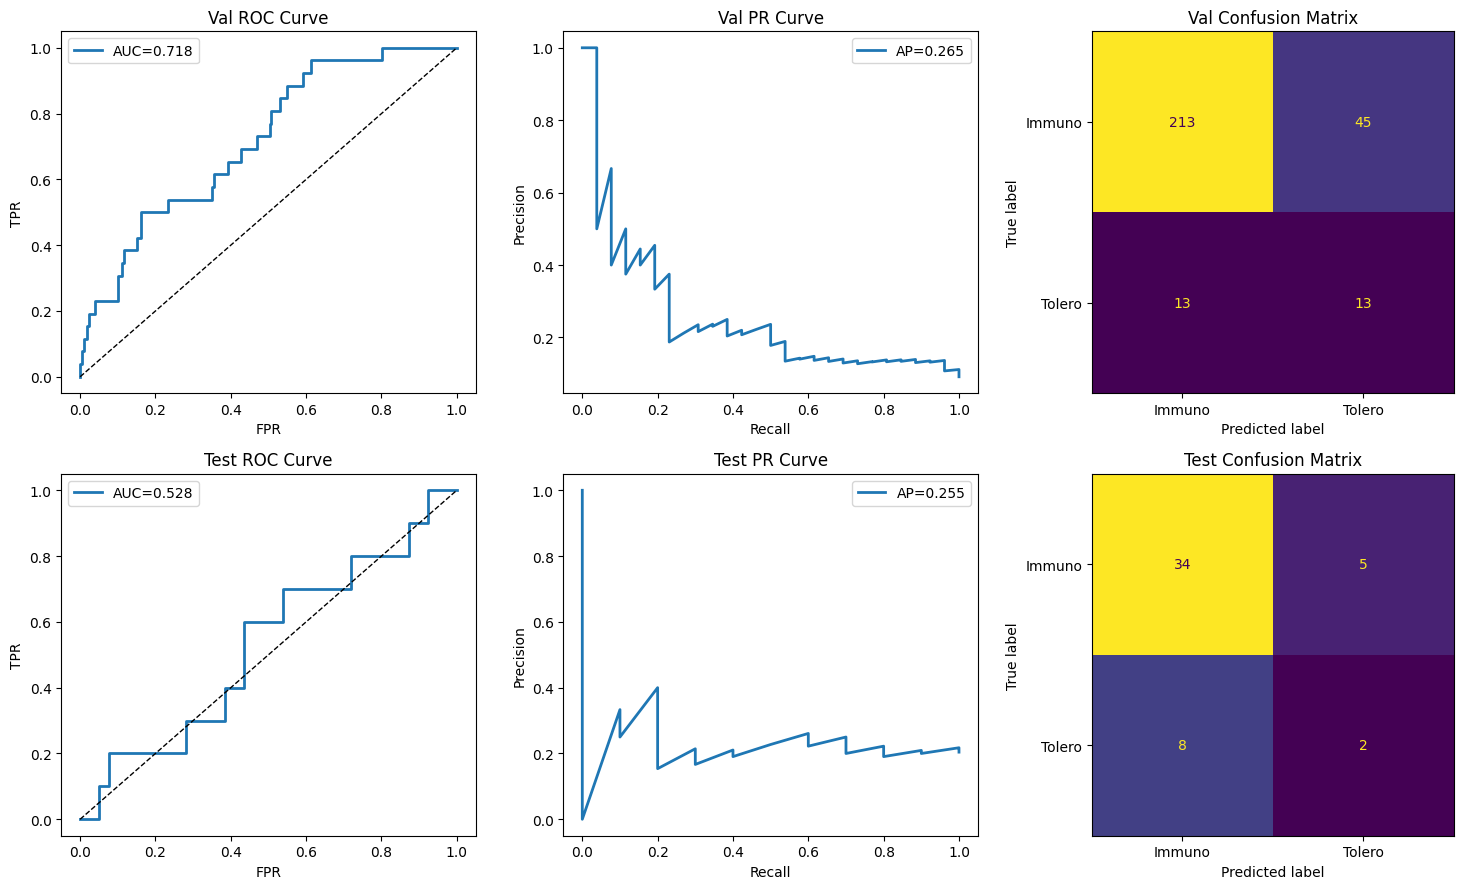

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row_idx, (split_name, probs, labels, metrics) in enumerate([
    ('Val',  val_probs,  val_labels,  val_metrics),
    ('Test', test_probs, test_labels, test_metrics),
]):
    fpr, tpr, _ = roc_curve(labels, probs)
    ax = axes[row_idx, 0]
    ax.plot(fpr, tpr, lw=2, label=f'AUC={metrics["auc_roc"]:.3f}')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'{split_name} ROC Curve'); ax.legend()

    prec, rec, _ = precision_recall_curve(labels, probs)
    ax = axes[row_idx, 1]
    ax.plot(rec, prec, lw=2, label=f'AP={metrics["auc_pr"]:.3f}')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'{split_name} PR Curve'); ax.legend()

    y_pred = (probs >= 0.5).astype(int)
    cm = confusion_matrix(labels, y_pred)
    ax = axes[row_idx, 2]
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Immuno', 'Tolero']).plot(
        ax=ax, colorbar=False)
    ax.set_title(f'{split_name} Confusion Matrix')

plt.tight_layout()
fig.savefig(CKPT_DIR / 'evaluation_plots.png', dpi=150, bbox_inches='tight')
print('Saved: evaluation_plots.png')


## 2. Score Distribution

Saved: score_distributions.png


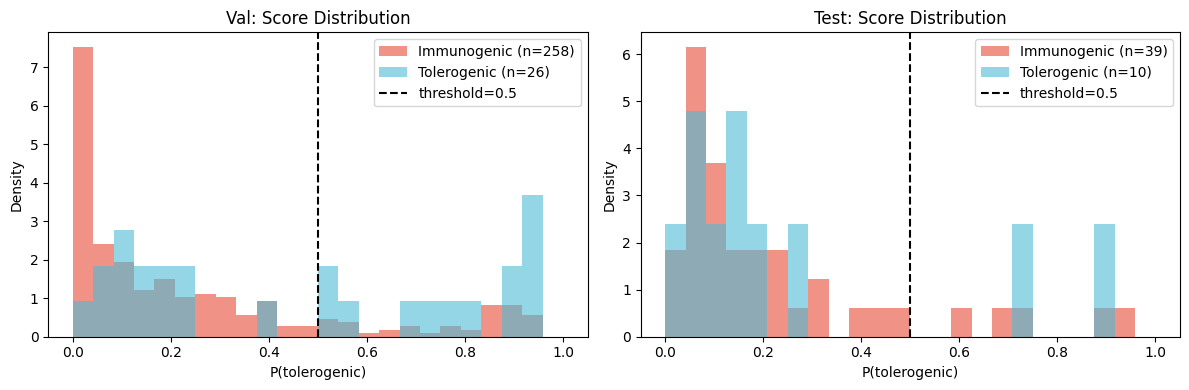

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (split_name, probs, labels) in zip(axes, [
    ('Val',  val_probs,  val_labels),
    ('Test', test_probs, test_labels),
]):
    immuno = probs[labels == 0]
    tolero = probs[labels == 1]
    bins = np.linspace(0, 1, 25)
    ax.hist(immuno, bins=bins, alpha=0.6, color='#e64b35',
            label=f'Immunogenic (n={len(immuno)})', density=True)
    ax.hist(tolero, bins=bins, alpha=0.6, color='#4dbbd5',
            label=f'Tolerogenic (n={len(tolero)})', density=True)
    ax.axvline(0.5, color='k', linestyle='--', lw=1.5, label='threshold=0.5')
    ax.set_xlabel('P(tolerogenic)'); ax.set_ylabel('Density')
    ax.set_title(f'{split_name}: Score Distribution'); ax.legend()

plt.tight_layout()
fig.savefig(CKPT_DIR / 'score_distributions.png', dpi=150, bbox_inches='tight')
print('Saved: score_distributions.png')


## 3. UMAP of TLS Embeddings

Running UMAP on TLS embeddings ...


/home/gpeng/miniconda3/envs/tls_spatial/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


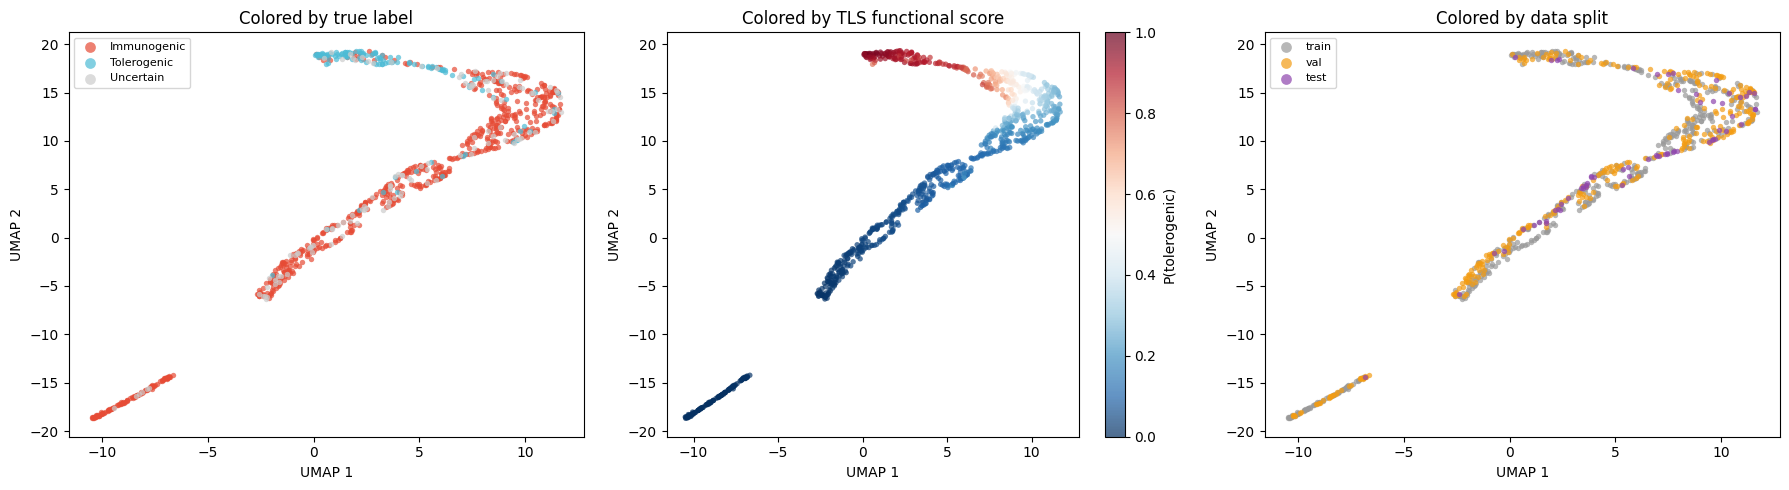

Saved: umap_embeddings.png
Updated tls_predictions.csv with UMAP coordinates


In [5]:
try:
    import umap
    has_umap = True
except ImportError:
    has_umap = False
    print('umap-learn not installed -- skipping. Install with: pip install umap-learn')

if has_umap:
    print('Running UMAP on TLS embeddings ...')
    reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.3)
    emb_2d  = reducer.fit_transform(embeddings.numpy())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    LABEL_COLORS = {0: '#e64b35', 1: '#4dbbd5', -1: '#cccccc'}
    LABEL_NAMES  = {0: 'Immunogenic', 1: 'Tolerogenic', -1: 'Uncertain'}

    ax = axes[0]
    for lbl, color in LABEL_COLORS.items():
        mask = pred_df['y_true'].values == lbl
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=color,
                   label=LABEL_NAMES[lbl], s=15, alpha=0.7, linewidths=0)
    ax.set_title('Colored by true label')
    ax.legend(markerscale=2, fontsize=8)
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

    ax = axes[1]
    sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                    c=pred_df['tls_functional_score'].values,
                    cmap='RdBu_r', s=15, alpha=0.7, linewidths=0, vmin=0, vmax=1)
    plt.colorbar(sc, ax=ax, label='P(tolerogenic)')
    ax.set_title('Colored by TLS functional score')
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

    ax = axes[2]
    for split_name, color in {'train': '#999999', 'val': '#f39c12', 'test': '#8e44ad'}.items():
        mask = pred_df['split'].values == split_name
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=color,
                   label=split_name, s=15, alpha=0.7, linewidths=0)
    ax.set_title('Colored by data split')
    ax.legend(markerscale=2, fontsize=8)
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

    plt.tight_layout()
    fig.savefig(CKPT_DIR / 'umap_embeddings.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: umap_embeddings.png')

    pred_df['umap1'] = emb_2d[:, 0]
    pred_df['umap2'] = emb_2d[:, 1]
    pred_df.to_csv(CKPT_DIR / 'tls_predictions.csv', index=False)
    print('Updated tls_predictions.csv with UMAP coordinates')


## 4. Summary for Notebook 05

In [6]:
print('=' * 55)
print('=== Summary for notebook 05 ===')
print('=' * 55)
print(f'Best checkpoint  : {CKPT_BEST}')
print(f'  epoch={ckpt["epoch"]}, val_auc={ckpt["val_auc"]:.4f}')
print()
print('Val metrics:')
for k, v in val_metrics.items():  print(f'  {k}: {v:.4f}')
print()
print('Test metrics:')
for k, v in test_metrics.items(): print(f'  {k}: {v:.4f}')
print()
print(f'Predictions CSV  : {CKPT_DIR}/tls_predictions.csv')
print(f'Embeddings PT    : {CKPT_DIR}/tls_embeddings.pt')
print()
print('Next: nb05 -- clinical validation')


=== Summary for notebook 05 ===
Best checkpoint  : /home/gpeng/projects/spatial_transcriptom/tls_functional_score/checkpoints/best_model.pt
  epoch=28, val_auc=0.7181

Val metrics:
  auc_roc: 0.7181
  auc_pr: 0.2649
  f1_macro: 0.5948
  accuracy: 0.7958

Test metrics:
  auc_roc: 0.5282
  auc_pr: 0.2545
  f1_macro: 0.5374
  accuracy: 0.7347

Predictions CSV  : /home/gpeng/projects/spatial_transcriptom/tls_functional_score/checkpoints/tls_predictions.csv
Embeddings PT    : /home/gpeng/projects/spatial_transcriptom/tls_functional_score/checkpoints/tls_embeddings.pt

Next: nb05 -- clinical validation


## 5. 5-Fold Sample-Level Cross-Validation

With only 2 samples per val/test in the main split, single-split metrics are noisy.
5-fold CV at the sample level gives a more honest estimate of generalisation: each fold
holds out ~5 samples (~2 with tolerogenic TLS) and retrains from scratch.

**Paper-ready numbers come from here, not from Section 1.**

Expected runtime: ~10-15 min on V100/A100 (80 epochs x 5 folds).


In [7]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

# ── Build sample inventory ─────────────────────────────────────────────────────
sample_info = {}
for g in graphs:
    sid = g.sample_id
    if sid not in sample_info:
        sample_info[sid] = {'n_tolero': 0, 'n_immuno': 0, 'n_graphs': 0}
    sample_info[sid]['n_graphs'] += 1
    y = int(g.y)
    if y == 1:
        sample_info[sid]['n_tolero'] += 1
    elif y == 0:
        sample_info[sid]['n_immuno'] += 1

all_samples = np.array(sorted(sample_info.keys()))
has_tolero  = np.array([sample_info[s]['n_tolero'] > 0 for s in all_samples], dtype=int)

print(f'Total samples: {len(all_samples)}')
print(f'  With tolerogenic TLS : {has_tolero.sum()}')
print(f'  Without tolerogenic  : {(has_tolero == 0).sum()}')
print()

for s in all_samples:
    info = sample_info[s]
    print(f'  {s}: immuno={info["n_immuno"]:3d}  tolero={info["n_tolero"]:3d}  '
          f'graphs={info["n_graphs"]:3d}  has_tol={info["n_tolero"]>0}')

# ── Fold definitions ──────────────────────────────────────────────────────────
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print(f'\n5-fold sample-level split (stratified by tolerogenic presence):')
for fold_idx, (tv_idx, test_idx) in enumerate(skf.split(all_samples, has_tolero)):
    tol_in_test = has_tolero[test_idx].sum()
    print(f'  Fold {fold_idx+1}: test={len(test_idx)} samples '
          f'({tol_in_test} with tolero) | train+val={len(tv_idx)} samples')

Total samples: 16
  With tolerogenic TLS : 9
  Without tolerogenic  : 7

  GSM5924030_ffpe_c_2: immuno= 86  tolero= 39  graphs=150  has_tol=True
  GSM5924031_ffpe_c_3: immuno=171  tolero= 38  graphs=240  has_tol=True
  GSM5924032_ffpe_c_4: immuno= 24  tolero=  1  graphs= 29  has_tol=True
  GSM5924033_ffpe_c_7: immuno=239  tolero= 21  graphs=281  has_tol=True
  GSM5924034_ffpe_c_10: immuno= 62  tolero=  4  graphs= 71  has_tol=True
  GSM5924035_ffpe_c_20: immuno= 14  tolero=  3  graphs= 22  has_tol=True
  GSM5924036_ffpe_c_21: immuno=  2  tolero=  0  graphs=  2  has_tol=False
  GSM5924037_ffpe_c_34: immuno= 37  tolero= 10  graphs= 64  has_tol=True
  GSM5924039_ffpe_c_39: immuno=  0  tolero=  0  graphs=  1  has_tol=False
  GSM5924042_frozen_a_1: immuno=  2  tolero=  0  graphs=  2  has_tol=False
  GSM5924044_frozen_a_15: immuno= 19  tolero=  5  graphs= 36  has_tol=True
  GSM5924046_frozen_b_1: immuno=  3  tolero=  0  graphs=  4  has_tol=False
  GSM5924048_frozen_b_13: immuno=  2  tolero=  

In [8]:
# ── CV hyperparameters ────────────────────────────────────────────────────────
CV_EPOCHS = 80     # fixed for all folds -- AUC from 3-4 tolero is too noisy to stop on
CV_T0     = 40     # cosine restart period

cv_results = []
t_cv_start = time.time()

for fold_idx, (tv_idx, test_idx) in enumerate(skf.split(all_samples, has_tolero)):
    test_samples      = set(all_samples[test_idx])
    train_val_samples = all_samples[tv_idx]

    # ── Simple random 20% inner val (no tolero-rich guarantee) ───────────────
    # Fix A: removing the tolero-rich-in-val guarantee -- it steals training
    # signal from the minority class more than it helps early stopping quality.
    rng = np.random.RandomState(SEED + fold_idx)
    n_inner_val = max(2, len(train_val_samples) // 5)
    inner_val_idx   = rng.choice(len(train_val_samples), size=n_inner_val, replace=False)
    inner_val_set   = set(train_val_samples[inner_val_idx])
    inner_train_set = set(train_val_samples) - inner_val_set

    # Graph lists
    fold_train_g = [g for g in graphs if g.sample_id in inner_train_set]
    fold_val_g   = [g for g in graphs if g.sample_id in inner_val_set]
    fold_test_g  = [g for g in graphs if g.sample_id in test_samples]

    n_tol_test      = sum(1 for g in fold_test_g  if int(g.y) == 1)
    n_lab_test      = sum(1 for g in fold_test_g  if int(g.y) >= 0)
    n_tol_train     = sum(1 for g in fold_train_g if int(g.y) == 1)
    n_tol_inner_val = sum(1 for g in fold_val_g   if int(g.y) == 1)

    print(f'\n{"="*60}')
    print(f'Fold {fold_idx+1}/{N_FOLDS}')
    print(f'  train : {len(fold_train_g)} graphs ({len(inner_train_set)} samples, {n_tol_train} tolero)')
    print(f'  val   : {len(fold_val_g)} graphs ({len(inner_val_set)} samples, {n_tol_inner_val} tolero)')
    print(f'  test  : {len(fold_test_g)} graphs ({len(test_samples)} samples, '
          f'{n_tol_test}/{n_lab_test} tolero)')
    print(f'  test samples: {sorted(test_samples)}', flush=True)
    # Fix B: always fixed epochs -- no early stopping in CV
    print(f'  Training: fixed {CV_EPOCHS} epochs (no early stopping)', flush=True)

    if len(fold_train_g) == 0 or n_lab_test == 0:
        print('  Skipping: no training data or no labeled test graphs', flush=True)
        continue

    # Class weights for this fold
    fold_n_imm = sum(1 for g in fold_train_g if int(g.y) == 0)
    fold_n_tol = max(sum(1 for g in fold_train_g if int(g.y) == 1), 1)
    fold_n_lab = fold_n_imm + fold_n_tol
    fold_cw = torch.tensor([
        fold_n_lab / (2 * max(fold_n_imm, 1)),
        fold_n_lab / (2 * fold_n_tol),
    ], dtype=torch.float32).to(DEVICE)
    print(f'  class weights: immuno={fold_cw[0]:.3f}, tolero={fold_cw[1]:.3f}', flush=True)

    # DataLoaders
    fl_train = DataLoader(fold_train_g, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    fl_val   = DataLoader(fold_val_g,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    fl_test  = DataLoader(fold_test_g,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Fresh model + optimizer
    fold_model = TLSFunctionalGNN(
        in_dim=IN_DIM, hidden=HIDDEN, n_classes=2,
        n_niche_clusters=K_NICHE, n_region_clusters=K_REGION,
        heads=HEADS, dropout=DROPOUT,
    ).to(DEVICE)
    fold_opt   = AdamW(fold_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    fold_sched = CosineAnnealingWarmRestarts(fold_opt, T_0=CV_T0, eta_min=1e-5)

    # Focal loss in every fold (Fix 2, unchanged)
    fold_loss = TLSTrainingLoss(
        task_weight=TASK_W, domain_weight=0.0,
        contrastive_weight=CONTRASTIVE_W, aux_weight=AUX_W,
        n_classes=2, class_weights=fold_cw,
        use_focal=True, focal_gamma=FOCAL_GAMMA,
    )

    # ── Fixed-epoch training (Fix B) ──────────────────────────────────────────
    fold_step  = 0
    fold_warmup = max(1, int(0.05 * CV_EPOCHS * len(fl_train)))
    t_fold = time.time()

    for ep in range(1, CV_EPOCHS + 1):
        _, fold_step = train_one_epoch(
            fold_model, fl_train, fold_opt, fold_loss, DEVICE, fold_step, fold_warmup
        )
        fold_sched.step(ep - 1)

    elapsed = time.time() - t_fold
    print(f'  Training done: {CV_EPOCHS} epochs in {elapsed:.0f}s', flush=True)

    # Evaluate on test fold
    test_m, test_prob, test_lbl = evaluate_loader(fold_model, fl_test, DEVICE)

    tol_recall = tol_prec = tol_f1 = float('nan')
    if n_tol_test > 0 and len(test_lbl) > 0:
        test_pred = (test_prob >= 0.5).astype(int)
        rep = classification_report(
            test_lbl, test_pred,
            target_names=['immunogenic', 'tolerogenic'],
            output_dict=True, zero_division=0
        )
        tol_recall = rep['tolerogenic']['recall']
        tol_prec   = rep['tolerogenic']['precision']
        tol_f1     = rep['tolerogenic']['f1-score']
        print(classification_report(
            test_lbl, test_pred,
            target_names=['immunogenic', 'tolerogenic'],
            digits=3, zero_division=0
        ), flush=True)

    print(f'  AUC-ROC={test_m["auc_roc"]:.4f}  AUC-PR={test_m["auc_pr"]:.4f}  '
          f'tolero_recall={tol_recall:.3f}  tolero_f1={tol_f1:.3f}', flush=True)

    cv_results.append({
        'fold'          : fold_idx + 1,
        'test_samples'  : ', '.join(sorted(test_samples)),
        'n_labeled'     : n_lab_test,
        'n_tol'         : n_tol_test,
        'n_tol_val'     : n_tol_inner_val,
        'auc_roc'       : test_m['auc_roc'],
        'auc_pr'        : test_m['auc_pr'],
        'f1_macro'      : test_m['f1_macro'],
        'accuracy'      : test_m['accuracy'],
        'tol_recall'    : tol_recall,
        'tol_precision' : tol_prec,
        'tol_f1'        : tol_f1,
    })

    del fold_model, fold_opt, fold_loss
    torch.cuda.empty_cache()

print(f'\nCV total time: {(time.time()-t_cv_start)/60:.1f} min')


Fold 1/5
  train : 386 graphs (10 samples, 63 tolero)
  val   : 5 graphs (2 samples, 0 tolero)
  test  : 524 graphs (4 samples, 59/471 tolero)
  test samples: ['GSM5924031_ffpe_c_3', 'GSM5924033_ffpe_c_7', 'GSM5924039_ffpe_c_39', 'GSM5924042_frozen_a_1']
  Training: fixed 80 epochs (no early stopping)
  class weights: immuno=0.625, tolero=2.492
  Training done: 80 epochs in 53s
              precision    recall  f1-score   support

 immunogenic      0.873     0.886     0.880       412
 tolerogenic      0.113     0.102     0.107        59

    accuracy                          0.788       471
   macro avg      0.493     0.494     0.493       471
weighted avg      0.778     0.788     0.783       471

  AUC-ROC=0.5477  AUC-PR=0.1367  tolero_recall=0.102  tolero_f1=0.107

Fold 2/5
  train : 789 graphs (11 samples, 104 tolero)
  val   : 66 graphs (2 samples, 10 tolero)
  test  : 60 graphs (3 samples, 8/43 tolero)
  test samples: ['GSM5924035_ffpe_c_20', 'GSM5924044_frozen_a_15', 'GSM592405

=== 5-Fold CV Results (per fold) ===

 fold  n_labeled  n_tol  n_tol_val  auc_roc  auc_pr  tol_recall  tol_precision  tol_f1  f1_macro  accuracy
    1        471     59          0    0.548   0.137       0.102          0.113   0.107     0.493     0.788
    2         43      8         10    0.646   0.270       0.375          0.250   0.300     0.544     0.674
    3         75     11          0    0.501   0.161       0.000          0.000   0.000     0.444     0.800
    4        130     40          5    0.524   0.345       0.000          0.000   0.000     0.398     0.662
    5         71      4         48    0.317   0.049       0.000          0.000   0.000     0.445     0.803

=== Mean +/- SD across 5/5 folds with tolerogenic test data ===

  auc_roc         : 0.507 +/- 0.120
  auc_pr          : 0.192 +/- 0.116
  tol_recall      : 0.095 +/- 0.162
  tol_precision   : 0.073 +/- 0.111
  tol_f1          : 0.081 +/- 0.131
  f1_macro        : 0.465 +/- 0.055
  accuracy        : 0.745 +/- 0.071

S

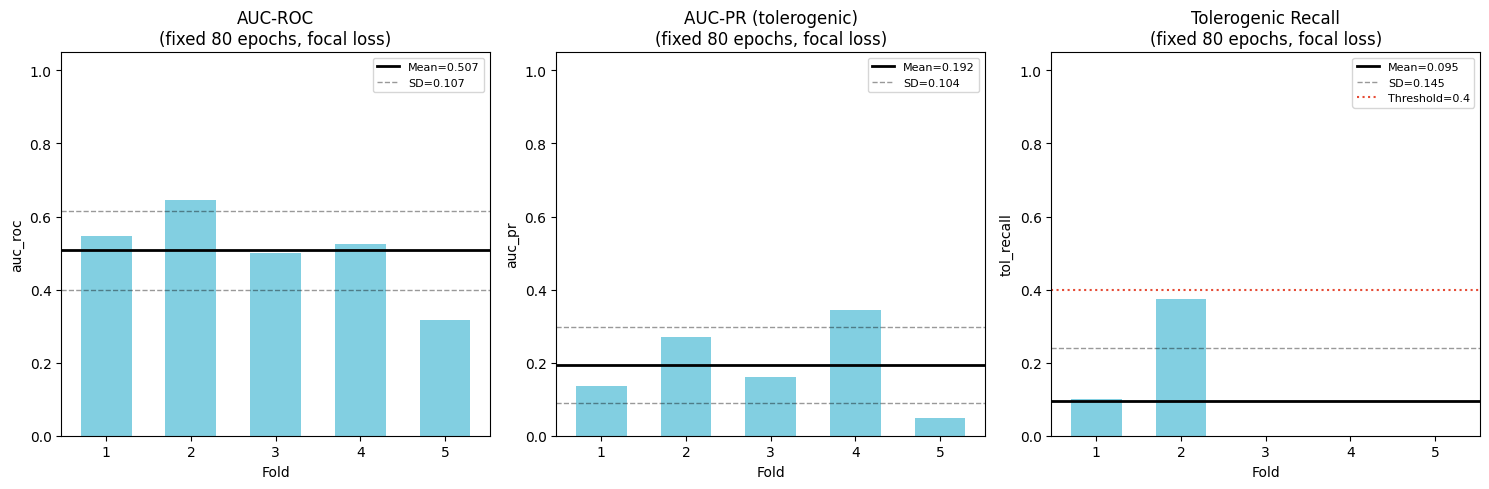

Saved: cv_results.png

=== Paper-ready line ===
5-fold CV AUC-ROC:            0.507 +/- 0.120
5-fold CV tolerogenic recall: 0.095 +/- 0.162

  Next steps: increase focal gamma, add graph augmentation,
  or review label quality before proceeding to notebook 05.


In [9]:
import math

cv_df = pd.DataFrame(cv_results)
cv_df.to_csv(CKPT_DIR / 'cv_results.csv', index=False)

# ── Per-fold table ─────────────────────────────────────────────────────────────
print('=== 5-Fold CV Results (per fold) ===\n')
cols = ['fold', 'n_labeled', 'n_tol', 'n_tol_val',
        'auc_roc', 'auc_pr', 'tol_recall', 'tol_precision', 'tol_f1', 'f1_macro', 'accuracy']
print(cv_df[cols].to_string(index=False,
      float_format=lambda x: f'{x:.3f}' if isinstance(x, float) and not math.isnan(x) else str(x)))

# ── Summary statistics ─────────────────────────────────────────────────────────
valid_cv    = cv_df[cv_df['n_tol'] > 0]
metric_cols = ['auc_roc', 'auc_pr', 'tol_recall', 'tol_precision', 'tol_f1', 'f1_macro', 'accuracy']

print(f'\n=== Mean +/- SD across {len(valid_cv)}/{len(cv_df)} folds with tolerogenic test data ===\n')
summary_rows = []
for col in metric_cols:
    vals = valid_cv[col].dropna()
    mean, std = vals.mean(), vals.std()
    print(f'  {col:16s}: {mean:.3f} +/- {std:.3f}')
    summary_rows.append({'metric': col, 'mean': mean, 'std': std, 'n_folds': len(vals)})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(CKPT_DIR / 'cv_summary.csv', index=False)
print('\nSaved: cv_results.csv, cv_summary.csv')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

key_metrics = ['auc_roc', 'auc_pr', 'tol_recall']
titles      = ['AUC-ROC', 'AUC-PR (tolerogenic)', 'Tolerogenic Recall']
thresholds  = [None, None, 0.4]

for ax, metric, title, thresh in zip(axes, key_metrics, titles, thresholds):
    vals  = valid_cv[metric].dropna().values
    folds = valid_cv['fold'].values[:len(vals)]
    mean, std = vals.mean(), vals.std()

    ax.bar(folds, vals, color='#4dbbd5', alpha=0.7, width=0.6)
    ax.axhline(mean, color='black', lw=2, label=f'Mean={mean:.3f}')
    ax.axhline(mean + std, color='black', lw=1, linestyle='--', alpha=0.4)
    ax.axhline(mean - std, color='black', lw=1, linestyle='--', alpha=0.4,
               label=f'SD={std:.3f}')
    if thresh is not None:
        ax.axhline(thresh, color='#e64b35', lw=1.5, linestyle=':', label=f'Threshold={thresh}')
    ax.set_xlabel('Fold')
    ax.set_ylabel(metric)
    ax.set_title(title + f'\n(fixed {CV_EPOCHS} epochs, focal loss)')
    ax.set_xticks(folds)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(CKPT_DIR / 'cv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cv_results.png')

# ── Paper-ready summary ────────────────────────────────────────────────────────
auc_m = summary_df.loc[summary_df['metric'] == 'auc_roc',    'mean'].values[0]
auc_s = summary_df.loc[summary_df['metric'] == 'auc_roc',    'std'].values[0]
rec_m = summary_df.loc[summary_df['metric'] == 'tol_recall', 'mean'].values[0]
rec_s = summary_df.loc[summary_df['metric'] == 'tol_recall', 'std'].values[0]

print()
print('=== Paper-ready line ===')
print(f'5-fold CV AUC-ROC:            {auc_m:.3f} +/- {auc_s:.3f}')
print(f'5-fold CV tolerogenic recall: {rec_m:.3f} +/- {rec_s:.3f}')
print()
if rec_m < 0.4:
    print('WARNING: mean tolerogenic recall still below 0.4.')
    print('  Next steps: increase focal gamma, add graph augmentation,')
    print('  or review label quality before proceeding to notebook 05.')
else:
    print('Tolerogenic recall >= 0.4 -- proceed to notebook 05.')